In [3]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
from qiskit.quantum_info import SparsePauliOp

In [4]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

In [5]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

### YQFWKNFQ_8AAs MPS run
- $R^2 = 0.999$
- 50k shots
- 800 COBYLA iterations

In [5]:
# Load the data
res_dir = "../res/fcc_hw/YQFWKNFQ_2025-01-31_aer_simulator_matrix_product_state/"
metadata_path = res_dir + "metadata.json"
opt_res_path = res_dir + "opt_results.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)
with open(opt_res_path, "r") as f:
    opt_res = json.load(f)

In [7]:
for key in opt_res:
    print(key)

final_cost
opt_params
cost_trajectory
top_solutions


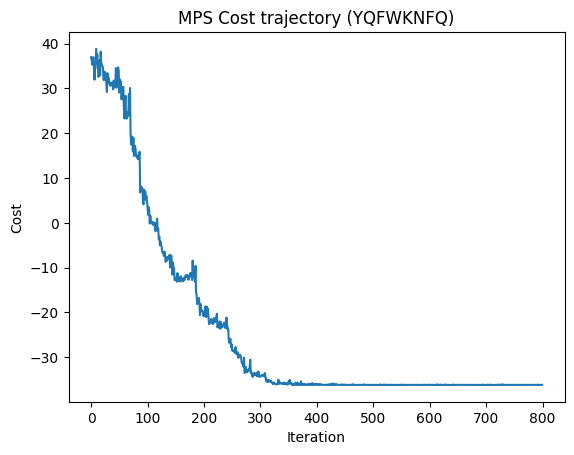

In [9]:
# Plot cost trajectory
plt.figure()
plt.plot(opt_res["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost trajectory (YQFWKNFQ)")
plt.show()

In [10]:
opt_res["top_solutions"][:10]

[['1011011101110000000011110111110011101001110', -36.168256937560024],
 ['1111011101110000000011110111110011101001110', -34.878256937560025],
 ['1011011101010000000011110111110011101001110', -34.62825693756002],
 ['0011011101110000000011110111110011101001110', -34.45825693756002],
 ['1111011101010000000011110111110011101001110', -33.33825693756002],
 ['1011011101110001000011110111110011101001110', -33.19825693756002],
 ['0111011101110000000011110111110011101001110', -33.168256937560024],
 ['1011001101110000000011110111110011101001110', -33.09825693756002],
 ['1010011101110000000011110111110011101001110', -33.058256937560024],
 ['0011011101010000000011110111110011101001110', -32.91825693756002]]

In [17]:
# Get top 100 solutions from MPS results
top_mps_bitstrings = [sol[0] for sol in opt_res["top_solutions"][:100]]
top_mps_turns = [convert_bitstring_to_turns(soln, metadata["main_seq"]) for soln in top_mps_bitstrings]

# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]

In [18]:
# Check overlapping ratio
overlap_soln_ratio = len(set(top_mps_turns).intersection(set(top_cls_solns))) / 100
print(f"Overlap ratio: {overlap_soln_ratio}")

Overlap ratio: 0.0


### YQFWKNFQ_8AAs MPS run
- $R^2 = 0.999$
- 50k shots
- 800 COBYLA iterations
- num_layers = 2

In [2]:
# Load the data
res_dir = "../res/fcc_hw/YQFWKNFQ_2025-02-03_aer_simulator_matrix_product_state/"
metadata_path = res_dir + "metadata.json"
opt_res_path = res_dir + "opt_results.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)
with open(opt_res_path, "r") as f:
    opt_res = json.load(f)

In [3]:
metadata

{'ansatz_repetitions': 2,
 'backend': 'aer_simulator_matrix_product_state',
 'chunk_size': 20,
 'circ_preparation_time (s)': 0.09,
 'hamiltonian_load_time (min)': 1.28,
 'main_seq': 'YQFWKNFQ',
 'max_iter': 800,
 'max_num_saved_states': 1000,
 'num_ham_terms': 4203123,
 'num_qubits': 43,
 'num_workers': 96,
 'optimizer': 'COBYLA',
 'parallelizer': 'ray',
 'r2_threshold': 0.999,
 'runner': 'aer',
 'session_id': None,
 'shots': 50000,
 'timestamp': '2025-02-03T17:03:26.052279+00:00'}

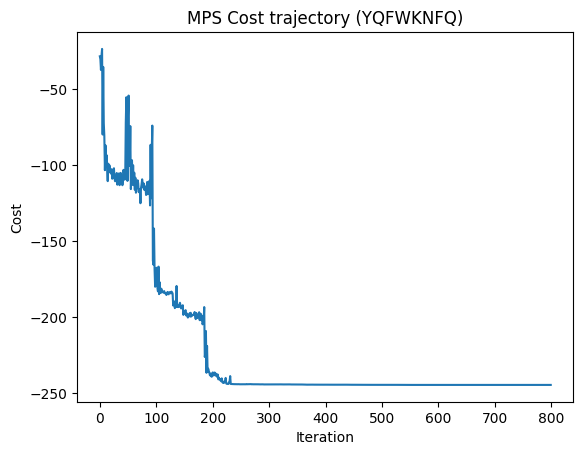

In [4]:
# Plot cost trajectory
plt.figure()
plt.plot(opt_res["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost trajectory (YQFWKNFQ)")
plt.show()

In [9]:
opt_res["top_solutions"][:10]

[['0010011000111100000101111011010110011110011', -244.4773766899903],
 ['0010011000111100000111111011010110011110011', -244.47080023913477],
 ['0010011000111100001101111011010110011110011', -244.46559970014403],
 ['0010011000111110000101111011010110011110011', -244.46387728743977],
 ['0010011000111100001111111011010110011110011', -244.4590232492885],
 ['0010011000111110000111111011010110011110011', -244.45730083658424],
 ['0010011001111100000101111011010110011110011', -244.45459412485363],
 ['0010011000111110001101111011010110011110011', -244.4521002975935],
 ['0010011000111100000001111011010110011110011', -244.4520908488953],
 ['0010001000111100000101111011010110011110011', -244.4487469824471]]

In [7]:
# Get top 100 solutions from MPS results
top_mps_bitstrings = [sol[0] for sol in opt_res["top_solutions"][:100]]
top_mps_turns = [convert_bitstring_to_turns(soln, metadata["main_seq"]) for soln in top_mps_bitstrings]

# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]

In [8]:
# Check overlapping ratio
overlap_soln_ratio = len(set(top_mps_turns).intersection(set(top_cls_solns))) / 100
print(f"Overlap ratio: {overlap_soln_ratio}")

Overlap ratio: 0.0


### YQFWKNFQ_8AAs MPS run
- $R^2 = 0.995$
- 100k shots
- 500 COBYLA iterations
- num_layers = 2

In [6]:
# Load the data
res_dir = "../res/fcc_hw/"
run_1_dir = res_dir + "YQFWKNFQ_2025-02-07-20-14-40_aer_simulator_matrix_product_state/"
run_2_dir = res_dir + "YQFWKNFQ_2025-03-04-19-59-22_aer_simulator_matrix_product_state/"

metadata_1_path = run_1_dir + "metadata.json"
metadata_2_path = run_2_dir + "metadata.json"
opt_res_1_path = run_1_dir + "opt_results.json"
opt_res_2_path = run_2_dir + "opt_results.json"

with open(metadata_1_path, "r") as f:
    metadata_1 = json.load(f)
with open(metadata_2_path, "r") as f:
    metadata_2 = json.load(f)
with open(opt_res_1_path, "r") as f:
    opt_res_1 = json.load(f)
with open(opt_res_2_path, "r") as f:
    opt_res_2 = json.load(f)

In [7]:
metadata

NameError: name 'metadata' is not defined

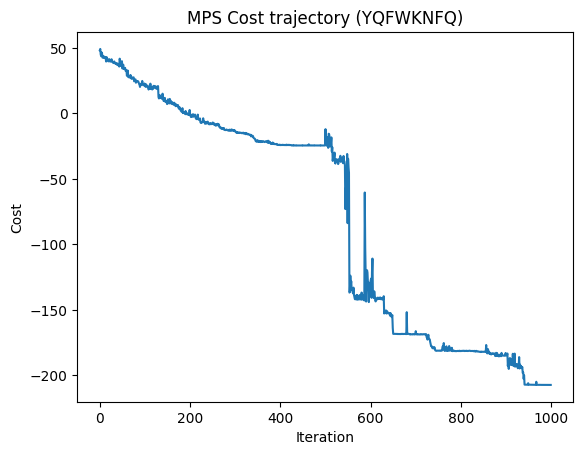

In [8]:
# Plot cost trajectory
total_cost_trajectory = opt_res_1["cost_trajectory"] + opt_res_2["cost_trajectory"]
plt.figure()
plt.plot(total_cost_trajectory)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost trajectory (YQFWKNFQ)")
plt.show()

In [9]:
opt_res_2["top_solutions"][:20]

[['1010001100001101000111000100010111000100000', -225.75544657144584],
 ['0001000000101101101100010100100110010100111', -207.43324138732996],
 ['0001010100101111001000010100100110010100111', -207.4285232072941],
 ['1001000100101101000100010100100110010100111', -207.42802375802972],
 ['0001010100101101000100010100100110010100111', -207.4268412474156],
 ['0001010100101101100100010100100110010100111', -207.42673521149518],
 ['1001000101101101101100010100100110010100111', -207.42475911145874],
 ['1001000100101111000100010100100110010100111', -207.42450908475297],
 ['1001000100101111100100010100100110010100111', -207.42440304883254],
 ['0001010100101111100100010100100110010100111', -207.42322053821843],
 ['1001010101101101101100010100100110010100111', -207.42308224547074],
 ['1001010100101111000100010100100110010100111', -207.42283221876497],
 ['1001010100101111100100010100100110010100111', -207.4227261828445],
 ['0001011000101101001100010100100110010100111', -207.42121754340076],
 ['100101

In [11]:
# Import Hamiltonian
def load_hamiltonian(file_name: str) -> dict:
    ham_dir = "fcc_hamilts/"
    with open(ham_dir + file_name, "r") as file:
        data = json.load(file)
        num_qubits = data["num_qubits"]
        sparse_op_list = [
            (pauli, qubits, coeff)
            for pauli, qubits, coeff in data["sparse_op_list"]
        ]
    hamilt = SparsePauliOp.from_sparse_list(sparse_op_list, num_qubits=num_qubits)
    return hamilt

hamilt_file = "YQFWKNFQ_8AAs_R2_995_1e-3.json"
qubit_op = load_hamiltonian(hamilt_file)

In [19]:
len(qubit_op)

4203123

In [12]:
from fcc.measurement_utils import _evaluate_sparsepauli

# Evaluate the energy of a solution
_evaluate_sparsepauli(state=opt_res_2["top_solutions"][0][0], observable=qubit_op)

-225.75544657144584

In [16]:
# Get top 100 solutions from MPS results
top_mps_bitstrings = [sol[0] for sol in opt_res_2["top_solutions"][:100]]
top_mps_turns = [convert_bitstring_to_turns(soln, metadata_2["main_seq"]) for soln in top_mps_bitstrings]

# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata_2['main_seq'])}AA_{metadata_2['main_seq']}_topobj.txt")[:100]
top_cls_turns = [sol[0] for sol in top_cls_solns]

In [17]:
top_cls_solns[:20]

[['603b590', -47.84],
 ['0a21390', -46.53],
 ['4b61390', -46.2],
 ['4279390', -45.97],
 ['693b490', -45.96],
 ['9634b90', -45.95],
 ['6863190', -45.93],
 ['593b490', -45.82],
 ['9134a90', -45.48],
 ['503b590', -45.45],
 ['6527490', -45.38],
 ['9a28b90', -45.37],
 ['703b590', -45.31],
 ['1836190', -45.31],
 ['607a190', -45.28],
 ['5527490', -45.24],
 ['60b3590', -45.24],
 ['9607b90', -45.19],
 ['170a190', -45.18],
 ['2a21390', -45.13]]

In [18]:
top_mps_turns[:20]

['xxxxx00',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420',
 '9429420']

In [17]:
print("MPS top 10:", top_mps_turns[:10])
print("Exhaustive search top 10:", top_cls_turns[:10])

MPS top 10: ['b52a490', 'b52a490', 'b52a490', '712a490', 'b52a490', '712a490', '9134a90', '7134a90', '7594490', 'b52a490']
Exhaustive search top 10: ['603b590', '0a21390', '4b61390', '4279390', '693b490', '9634b90', '6863190', '593b490', '9134a90', '503b590']


In [18]:
# Check overlapping ratio (top 100)
overlap_soln_ratio = len(set(top_mps_turns).intersection(set(top_cls_turns))) / 100
print(f"Overlap ratio: {overlap_soln_ratio}")

Overlap ratio: 0.03


In [19]:
# Check overlapping ratio (top 10)
overlap_soln_ratio = len(set(top_mps_turns[:10]).intersection(set(top_cls_turns[:10])))/10
print(f"Overlap ratio (top 10): {overlap_soln_ratio}")
print(f"Overlapping configurations (top 10): {set(top_mps_turns[:10]).intersection(set(top_cls_turns[:10]))}")

Overlap ratio (top 10): 0.1
Overlapping configurations (top 10): {'9134a90'}


In [ ]:
# Load Hamiltonian
ham_dir = "fcc_hamilts"
main_seq = "YQFWKNFQ"
file_name = f"{main_seq}_{len(main_seq)}AAs_R2_995_1e-3.json"